Couple_zodiac
Pisces_Virgo           80
Scorpio_Virgo          77
Sagittarius_Virgo      77
Gemini_Taurus          76
Pisces_Scorpio         76
                       ..
Taurus_Taurus          30
Aries_Aries            30
Leo_Leo                30
Gemini_Gemini          26
Capricorn_Capricorn    23
Name: count, Length: 78, dtype: int64


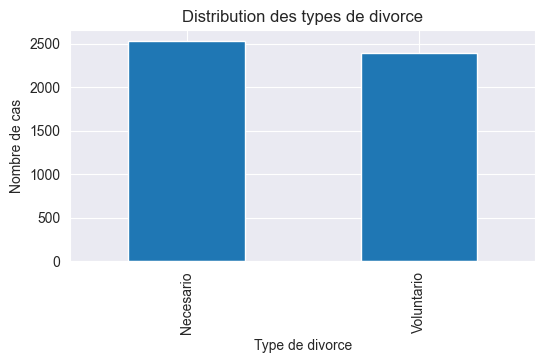

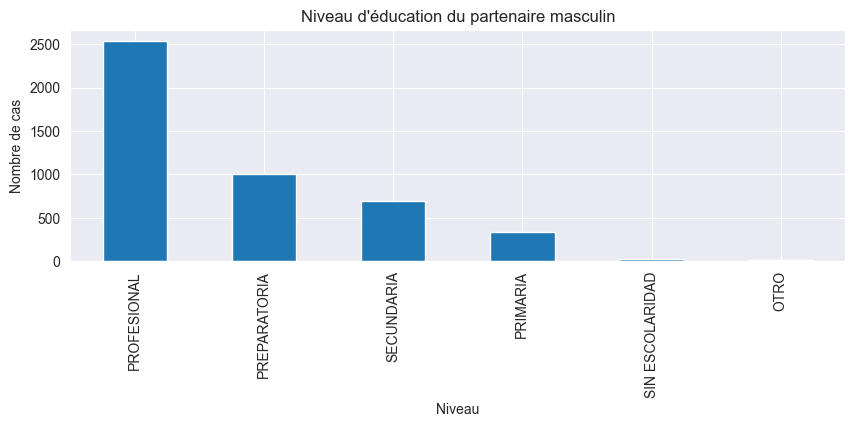

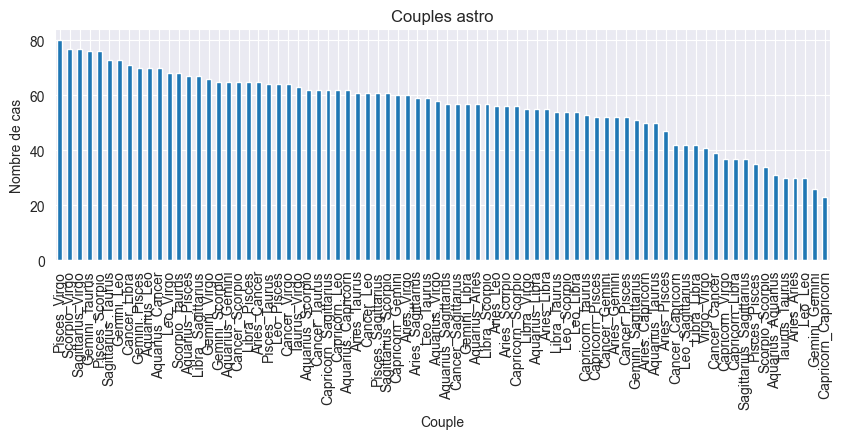

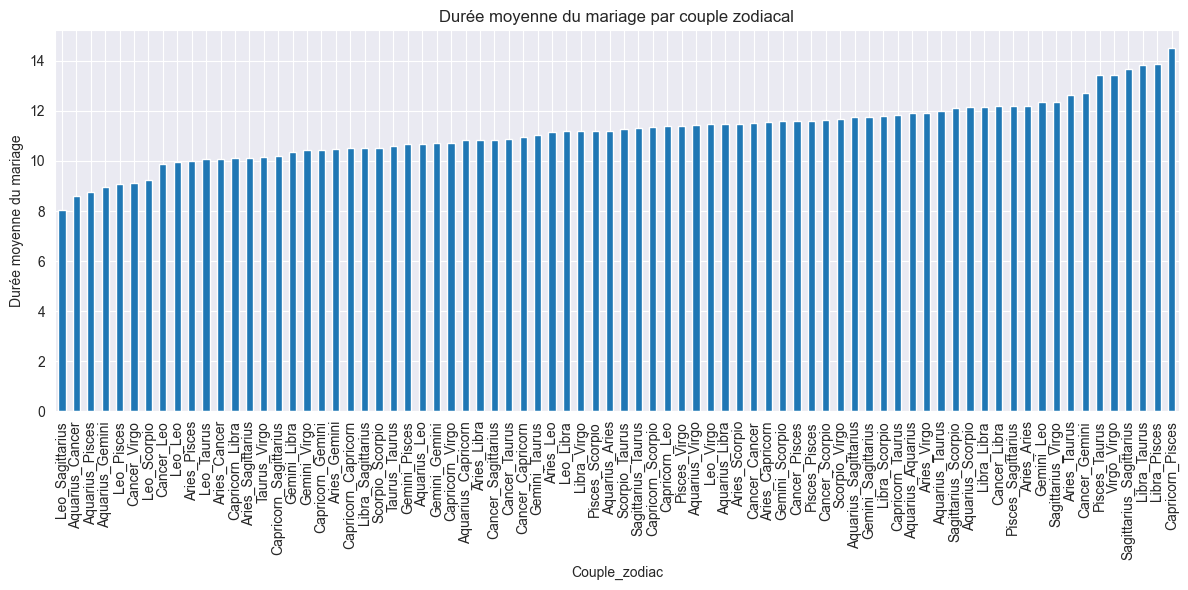

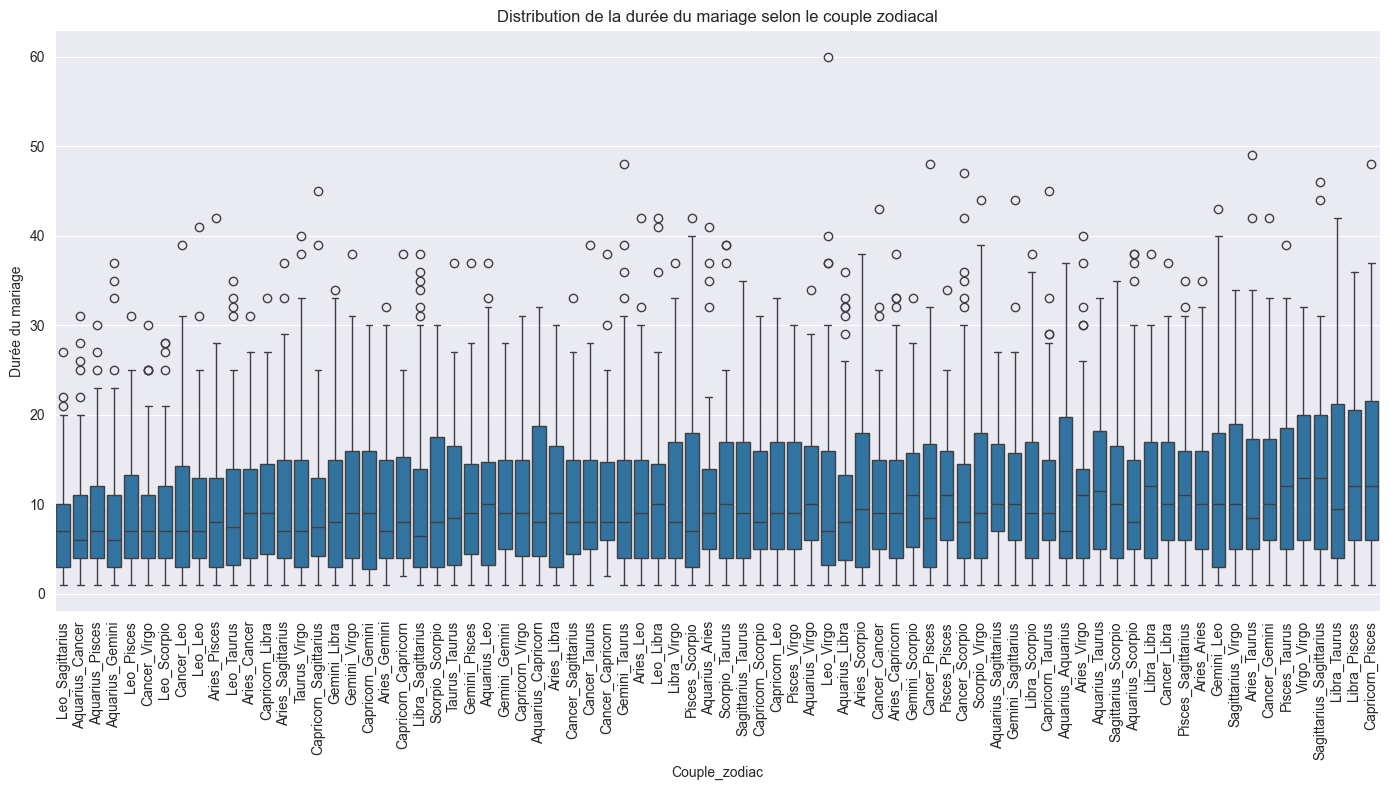

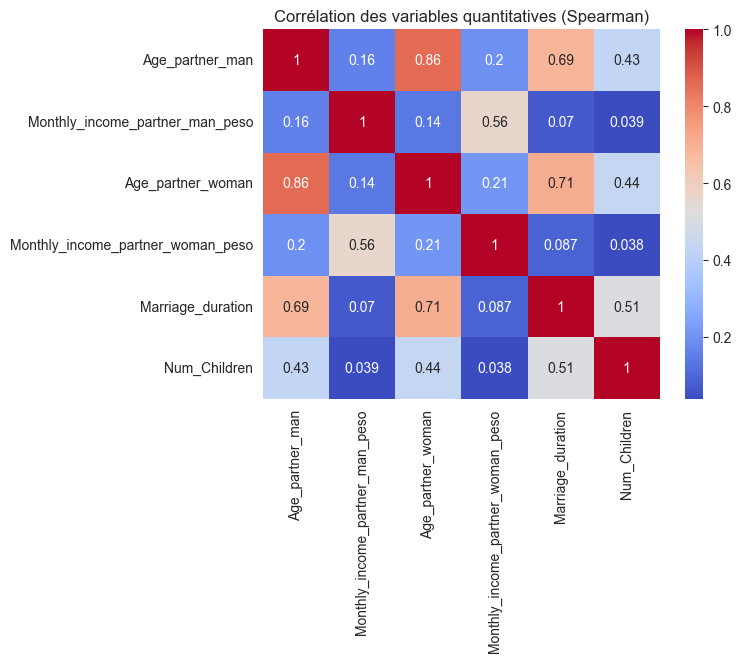

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold


df = pd.read_csv("data/divorces_2000-2015_translated.csv")

def zodiac_from_date(date_str):
    try:
        # gestion pd.NaT et floats (manquants)
        if pd.isnull(date_str):
            return None
        # conversion forcée (dayfirst pour J/M/AAAA)
        date = pd.to_datetime(date_str, dayfirst=True, errors='coerce')
        if pd.isnull(date):
            return None
        day = date.day
        month = date.month
        # Zodiaque
        zodiac_dates = [
            ((1, 20), (2, 18), "Aquarius"),
            ((2, 19), (3, 20), "Pisces"),
            ((3, 21), (4, 19), "Aries"),
            ((4, 20), (5, 20), "Taurus"),
            ((5, 21), (6, 20), "Gemini"),
            ((6, 21), (7, 22), "Cancer"),
            ((7, 23), (8, 22), "Leo"),
            ((8, 23), (9, 22), "Virgo"),
            ((9, 23), (10, 22), "Libra"),
            ((10, 23), (11, 21), "Scorpio"),
            ((11, 22), (12, 21), "Sagittarius"),
            ((12, 22), (1, 19), "Capricorn"),
        ]
        for start, end, sign in zodiac_dates:
            sm, sd = start
            em, ed = end
            if (month == sm and day >= sd) or (month == em and day <= ed):
                return sign
        if (month == 12 and day >= 22) or (month == 1 and day <= 19):
            return "Capricorn"
        return None
    except Exception:
        return None

def couple_zodiac(s1, s2):
    # gère valeurs manquantes avec tri
    if pd.isnull(s1) or pd.isnull(s2):
        return None
    return "_".join(sorted([s1, s2]))



#transformation des colonnes
df['Zodiac_partner_man'] = df['DOB_partner_man'].apply(zodiac_from_date)
df['Zodiac_partner_woman'] = df['DOB_partner_woman'].apply(zodiac_from_date)
df['Couple_zodiac'] = df.apply(lambda row: couple_zodiac(row['Zodiac_partner_man'], row['Zodiac_partner_woman']), axis=1)
print(df['Couple_zodiac'].value_counts())


# Distribution des types de divorce
plt.figure(figsize=(6,3))
df['Type_of_divorce'].value_counts().plot(kind='bar')
plt.title("Distribution des types de divorce")
plt.xlabel("Type de divorce")
plt.ylabel("Nombre de cas")
plt.show()


# Distribution du niveau d'éducation (partenaire homme)
plt.figure(figsize=(10,3))
df['Level_of_education_partner_man'].value_counts().plot(kind='bar')
plt.title("Niveau d'éducation du partenaire masculin")
plt.xlabel("Niveau")
plt.ylabel("Nombre de cas")
plt.show()

# Distribution des couples en signes astro
plt.figure(figsize=(10,3))
df['Couple_zodiac'].value_counts().plot(kind='bar')
plt.title("Couples astro")
plt.xlabel("Couple")
plt.ylabel("Nombre de cas")
plt.show()

# Distribution des durées moyenne de marriage par couples de signes astro
grouped = df.groupby('Couple_zodiac')['Marriage_duration'].mean().sort_values()

plt.figure(figsize=(12,6))
grouped.plot(kind='bar')
plt.ylabel("Durée moyenne du mariage")
plt.title("Durée moyenne du mariage par couple zodiacal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,8))
sns.boxplot(x="Couple_zodiac", y="Marriage_duration", data=df, order=grouped.index)
plt.ylabel("Durée du mariage")
plt.title("Distribution de la durée du mariage selon le couple zodiacal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Corrélation entre variables quantitatives
quant_vars = ['Age_partner_man','Monthly_income_partner_man_peso','Age_partner_woman','Monthly_income_partner_woman_peso','Marriage_duration','Num_Children']
corr_matrix = df[quant_vars].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation des variables quantitatives (Spearman)")
plt.show()





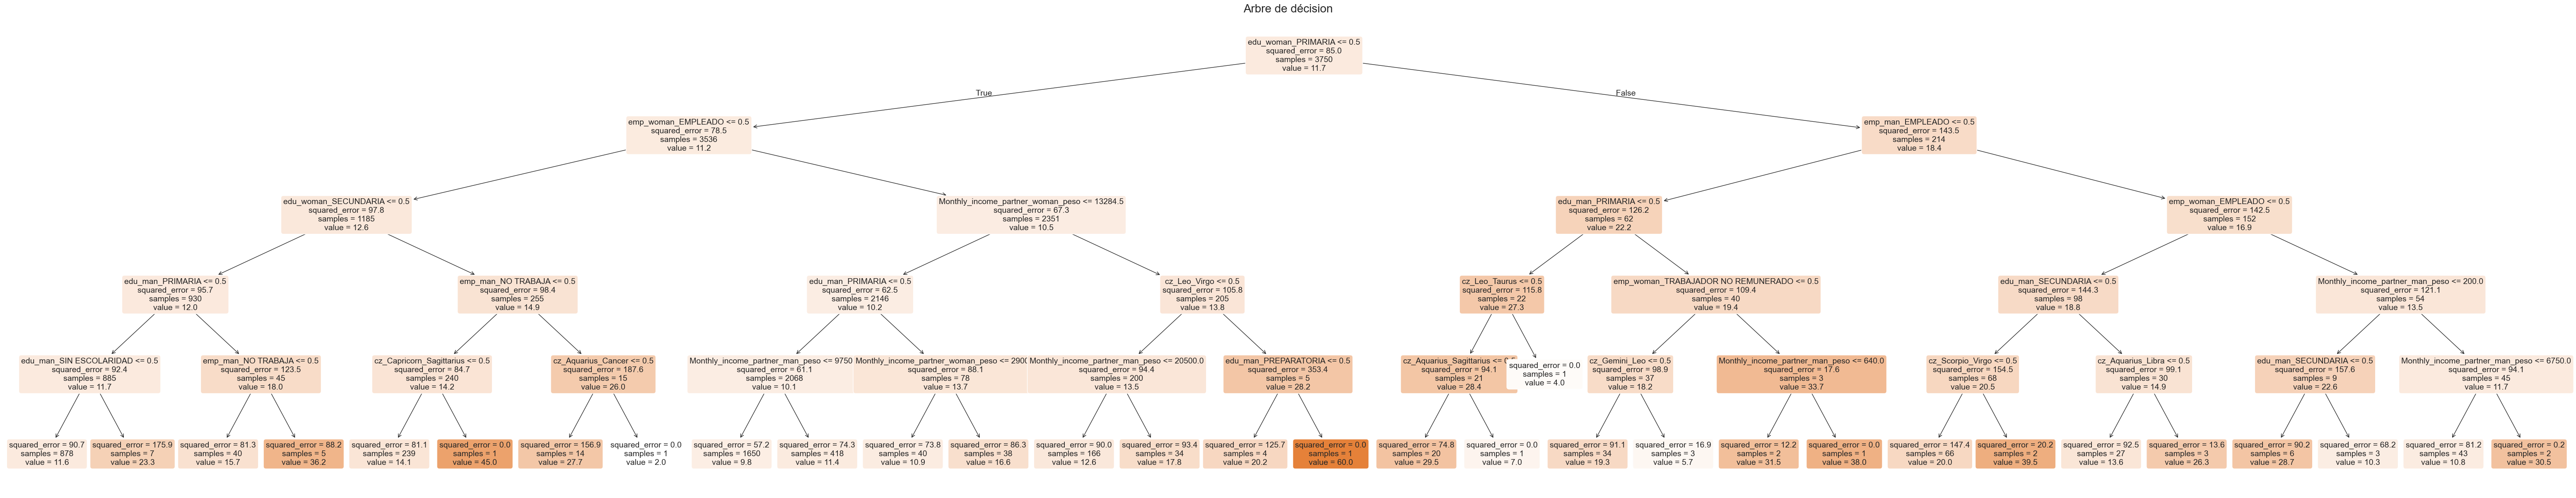

edu_woman_PRIMARIA                    0.254443
emp_woman_EMPLEADO                    0.108387
emp_man_NO TRABAJA                    0.092687
edu_man_PRIMARIA                      0.086714
Monthly_income_partner_man_peso       0.079388
Monthly_income_partner_woman_peso     0.074350
edu_woman_SECUNDARIA                  0.041721
edu_man_SECUNDARIA                    0.032465
edu_man_PREPARATORIA                  0.030732
emp_man_EMPLEADO                      0.029507
cz_Leo_Virgo                          0.025750
cz_Capricorn_Sagittarius              0.023085
edu_man_SIN ESCOLARIDAD               0.022992
cz_Scorpio_Virgo                      0.018001
emp_woman_TRABAJADOR NO REMUNERADO    0.016162
cz_Aquarius_Cancer                    0.015004
cz_Leo_Taurus                         0.013849
cz_Gemini_Leo                         0.012447
cz_Aquarius_Sagittarius               0.011722
cz_Aquarius_Libra                     0.010594
dtype: float64


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Encodage one-hot des variables catégorielles
X = pd.concat([
    pd.get_dummies(df['Employment_status_partner_man'], prefix='emp_man'),
    pd.get_dummies(df['Employment_status_partner_woman'], prefix='emp_woman'),
    pd.get_dummies(df['Level_of_education_partner_man'], prefix='edu_man'),
    pd.get_dummies(df['Level_of_education_partner_woman'], prefix='edu_woman'),
    df[['Monthly_income_partner_man_peso', 'Monthly_income_partner_woman_peso']].fillna(0),
    pd.get_dummies(df['Couple_zodiac'], prefix='cz')
], axis=1)

# Variable cible (durée du mariage en années)
y = df['Marriage_duration']

# Retirer les lignes avec NaN dans la cible
mask = y.notnull()
X_clean = X[mask]
y_clean = y[mask]

# Split apprentissage/test
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Arbre de régression
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train, y_train)

plt.figure(figsize=(80,15))
plot_tree(
    reg,
    feature_names=X_clean.columns,
    filled=True,
    rounded=True,
    fontsize=14,
    precision=1
)
plt.title("Arbre de décision", fontsize=20)
plt.show()

# Importance des variables
importances = pd.Series(reg.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print(importances[importances > 0])  # Affiche les variables ayant un impact



In [3]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Validation croisée pour l'arbre de décision
kf = KFold(n_splits=5, shuffle=True, random_state=42)
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
rmse_scores = []
for train_index, test_index in kf.split(X_clean):
    X_train, X_test = X_clean.iloc[train_index], X_clean.iloc[test_index]
    y_train, y_test = y_clean.iloc[train_index], y_clean.iloc[test_index]
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    rmse_scores.append(rmse)
print("Arbre de décision - RMSE moyen:", np.mean(rmse_scores))

# Validation croisée pour le Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rmse_scores_rf = []
for train_index, test_index in kf.split(X_clean):
    X_train, X_test = X_clean.iloc[train_index], X_clean.iloc[test_index]
    y_train, y_test = y_clean.iloc[train_index], y_clean.iloc[test_index]
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    rmse_scores_rf.append(rmse)
print("Random Forest - RMSE moyen:", np.mean(rmse_scores_rf))


Arbre de décision - RMSE moyen: 9.184854364961915
Random Forest - RMSE moyen: 9.778712074739888


In [4]:
def cross_validate_regression(model, X, y, feature_names):
    X = X[feature_names]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = mse ** 0.5
        rmse_scores.append(rmse)
    return np.mean(rmse_scores)

# Comparaison de sous-ensembles de variables
models = [DecisionTreeRegressor(max_depth=5, random_state=42), RandomForestRegressor(n_estimators=100, random_state=42)]
astro = [col for col in X_clean.columns if col.startswith('cz_')]
socio_eco = [col for col in X_clean.columns if 'income' in col or col.startswith('edu_') or col.startswith('emp')]

for model in models:
    print(model, "Astro")
    print("RMSE:", cross_validate_regression(model, X_clean, y_clean, astro))
    print(model, "Socio-éco")
    print("RMSE:", cross_validate_regression(model, X_clean, y_clean, socio_eco))


DecisionTreeRegressor(max_depth=5, random_state=42) Astro
RMSE: 9.292577654061557
DecisionTreeRegressor(max_depth=5, random_state=42) Socio-éco
RMSE: 9.158391161278791
RandomForestRegressor(random_state=42) Astro
RMSE: 9.247451121863282
RandomForestRegressor(random_state=42) Socio-éco
RMSE: 9.66863502417454


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Liste des variables catégorielles
cat_vars = [
    'Occupation_partner_man',
    'Occupation_partner_woman',
    'Level_of_education_partner_man',
    'Level_of_education_partner_woman',
    'Couple_zodiac'
]

# Encode les catégories par des entiers arbitraires
for col in cat_vars:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Variables explicatives (catégorielles et quantitatives mélangées)
vars_pred = [
    'Occupation_partner_man', 'Occupation_partner_woman',
    'Level_of_education_partner_man', 'Level_of_education_partner_woman',
    'Couple_zodiac',
    'Monthly_income_partner_man_peso', 'Monthly_income_partner_woman_peso', 'Num_Children'
]

X = df[vars_pred].fillna(0)
y = df['Marriage_duration']

mask = y.notnull()
X_clean = X[mask]
y_clean = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train, y_train)

plt.figure(figsize=(60,15))
plot_tree(
    reg,
    feature_names=X_clean.columns,
    filled=True,
    rounded=True,
    fontsize=14,
    precision=1
)
plot_tree(reg, feature_names=X.columns, filled=True)
plt.title("Arbre de décision mixte (catégorielle et continue, sans one-hot)")
plt.show()
